<a href="https://colab.research.google.com/github/Herrera1022/Modelo_afluencia_metro_pruebas/blob/main/gradient_boosting_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Herrera1022/Modelo_afluencia_metro_pruebas.git
import os
os.chdir("Modelo_afluencia_metro_pruebas")
!ls

Cloning into 'Modelo_afluencia_metro_pruebas'...
remote: Enumerating objects: 113, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 113 (delta 63), reused 64 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (113/113), 13.68 MiB | 10.39 MiB/s, done.
Resolving deltas: 100% (63/63), done.
 afluencia_metro_2024_transformado.csv	'Paper primera entrega.pdf'
 Afluencia_Metro_2024.xlsx		 README.md
 Exploracion_inicial.ipynb		 regresion.ipynb
 knn_model.ipynb			 splits


In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.utils import resample
import matplotlib.pyplot as plt

In [3]:
X_train      = pd.read_csv("./splits/X_train.csv")
y_train      = pd.read_csv("./splits/y_train.csv").squeeze()

X_validation = pd.read_csv("./splits/X_validation.csv")
y_validation = pd.read_csv("./splits/y_validation.csv").squeeze()

X_test       = pd.read_csv("./splits/X_test.csv")
y_test       = pd.read_csv("./splits/y_test.csv").squeeze()

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_validation.shape}")
print(f"Test:       {X_test.shape}")

Train:      (59899, 22)
Validation: (6947, 22)
Test:       (13611, 22)


## Búsqueda de hiperparámetros — Malla inicial (exploración rápida)
Probamos combinaciones representativas para identificar la zona de mejores hiperparámetros sin agotar el tiempo de cómputo.

In [12]:
param_grid = [
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1},
    {"n_estimators": 100, "max_depth": 5, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 7, "learning_rate": 0.05},
]

resultados = []

for i, params in enumerate(param_grid):
    print(f"[{i+1}/{len(param_grid)}] n_estimators={params['n_estimators']} | max_depth={params['max_depth']} | learning_rate={params['learning_rate']}")

    modelo = GradientBoostingRegressor(
        n_estimators  = params["n_estimators"],
        max_depth     = params["max_depth"],
        learning_rate = params["learning_rate"],
        random_state  = 42
    )
    modelo.fit(X_train, y_train)
    pred_val = modelo.predict(X_validation)

    rmse = np.sqrt(mean_squared_error(y_validation, pred_val))
    mae  = mean_absolute_error(y_validation, pred_val)
    mape = mean_absolute_percentage_error(y_validation, pred_val) * 100
    r2   = r2_score(y_validation, pred_val)

    resultados.append({
        "n_estimators":  params["n_estimators"],
        "max_depth":     params["max_depth"],
        "learning_rate": params["learning_rate"],
        "RMSE_val": round(rmse, 2),
        "MAE_val":  round(mae, 2),
        "MAPE_val": round(mape, 2),
        "R2_val":   round(r2, 4)
    })

    print(f"  RMSE={rmse:.2f} | MAE={mae:.2f} | MAPE={mape:.2f}% | R²={r2:.4f}")

df_resultados = pd.DataFrame(resultados)
print("\n=== RESULTADOS ORDENADOS POR RMSE ===")
print(df_resultados.sort_values("RMSE_val").to_string(index=False))

[1/8] n_estimators=100 | max_depth=3 | learning_rate=0.1
  RMSE=1182.52 | MAE=350.22 | MAPE=284.68% | R²=0.9869
[2/8] n_estimators=100 | max_depth=5 | learning_rate=0.1
  RMSE=1167.69 | MAE=286.48 | MAPE=193.92% | R²=0.9872
[3/8] n_estimators=200 | max_depth=3 | learning_rate=0.1
  RMSE=1159.95 | MAE=326.09 | MAPE=211.18% | R²=0.9874
[4/8] n_estimators=200 | max_depth=5 | learning_rate=0.1
  RMSE=1179.33 | MAE=280.80 | MAPE=152.71% | R²=0.9870
[5/8] n_estimators=200 | max_depth=3 | learning_rate=0.05
  RMSE=1158.53 | MAE=347.24 | MAPE=277.62% | R²=0.9874
[6/8] n_estimators=200 | max_depth=5 | learning_rate=0.05
  RMSE=1190.01 | MAE=287.10 | MAPE=194.19% | R²=0.9867
[7/8] n_estimators=300 | max_depth=5 | learning_rate=0.05
  RMSE=1203.61 | MAE=284.00 | MAPE=167.82% | R²=0.9864
[8/8] n_estimators=300 | max_depth=7 | learning_rate=0.05
  RMSE=1149.93 | MAE=251.21 | MAPE=94.92% | R²=0.9876

=== RESULTADOS ORDENADOS POR RMSE ===
 n_estimators  max_depth  learning_rate  RMSE_val  MAE_val  MA

## Búsqueda de hiperparámetros — Malla refinada
Con base en la fase 1, identificamos que max_depth=7 y learning_rate=0.05 son prometedores. Refinamos explorando más estimadores y learning_rate más bajo.

In [13]:
param_grid_2 = [
    {"n_estimators": 300, "max_depth": 7, "learning_rate": 0.05},
    {"n_estimators": 400, "max_depth": 7, "learning_rate": 0.05},
    {"n_estimators": 500, "max_depth": 7, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 7, "learning_rate": 0.01},
    {"n_estimators": 500, "max_depth": 7, "learning_rate": 0.01},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.01},
    {"n_estimators": 500, "max_depth": 5, "learning_rate": 0.01},
]

resultados_2 = []

for i, params in enumerate(param_grid_2):
    print(f"[{i+1}/{len(param_grid_2)}] n_estimators={params['n_estimators']} | max_depth={params['max_depth']} | learning_rate={params['learning_rate']}")

    modelo = GradientBoostingRegressor(
        n_estimators  = params["n_estimators"],
        max_depth     = params["max_depth"],
        learning_rate = params["learning_rate"],
        random_state  = 42
    )
    modelo.fit(X_train, y_train)
    pred_val = modelo.predict(X_validation)

    rmse = np.sqrt(mean_squared_error(y_validation, pred_val))
    mae  = mean_absolute_error(y_validation, pred_val)
    mape = mean_absolute_percentage_error(y_validation, pred_val) * 100
    r2   = r2_score(y_validation, pred_val)

    resultados_2.append({
        "n_estimators":  params["n_estimators"],
        "max_depth":     params["max_depth"],
        "learning_rate": params["learning_rate"],
        "RMSE_val": round(rmse, 2),
        "MAE_val":  round(mae, 2),
        "MAPE_val": round(mape, 2),
        "R2_val":   round(r2, 4)
    })

    print(f"  RMSE={rmse:.2f} | MAE={mae:.2f} | MAPE={mape:.2f}% | R²={r2:.4f}")

df_todos = pd.concat([df_resultados, df_resultados_2], ignore_index=True)
print("\n=== TODOS LOS RESULTADOS ORDENADOS POR RMSE ===")
print(df_todos.sort_values("RMSE_val").to_string(index=False))

[1/7] n_estimators=300 | max_depth=7 | learning_rate=0.05
  RMSE=1149.93 | MAE=251.21 | MAPE=94.92% | R²=0.9876
[2/7] n_estimators=400 | max_depth=7 | learning_rate=0.05
  RMSE=1152.84 | MAE=250.46 | MAPE=82.06% | R²=0.9876
[3/7] n_estimators=500 | max_depth=7 | learning_rate=0.05
  RMSE=1154.21 | MAE=249.67 | MAPE=77.45% | R²=0.9875
[4/7] n_estimators=300 | max_depth=7 | learning_rate=0.01
  RMSE=1242.89 | MAE=395.89 | MAPE=545.46% | R²=0.9855
[5/7] n_estimators=500 | max_depth=7 | learning_rate=0.01
  RMSE=1125.25 | MAE=262.43 | MAPE=185.06% | R²=0.9881
[6/7] n_estimators=300 | max_depth=5 | learning_rate=0.01
  RMSE=1285.73 | MAE=432.03 | MAPE=708.30% | R²=0.9845
[7/7] n_estimators=500 | max_depth=5 | learning_rate=0.01
  RMSE=1196.96 | MAE=312.82 | MAPE=345.31% | R²=0.9866

=== TODOS LOS RESULTADOS ORDENADOS POR RMSE ===
 n_estimators  max_depth  learning_rate  RMSE_val  MAE_val  MAPE_val  R2_val  RMSE_train
          500          7           0.01   1125.25      NaN    185.06     N

## Modelo final con mejores hiperparámetros: n_estimators=500, max_depth=7, learning_rate=0.01

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Modelo final
modelo_final = GradientBoostingRegressor(
    n_estimators  = 500,
    max_depth     = 7,
    learning_rate = 0.01,
    random_state  = 42
)
modelo_final.fit(X_train, y_train)

# Predicciones
pred_train = modelo_final.predict(X_train)
pred_val   = modelo_final.predict(X_validation)
pred_test  = modelo_final.predict(X_test)

# MAE (principal)
mae_train = mean_absolute_error(y_train, pred_train)
mae_val   = mean_absolute_error(y_validation, pred_val)
mae_test  = mean_absolute_error(y_test, pred_test)

# RMSE (complementaria)
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_val   = np.sqrt(mean_squared_error(y_validation, pred_val))
rmse_test  = np.sqrt(mean_squared_error(y_test, pred_test))

# R² (descriptiva)
r2_train = r2_score(y_train, pred_train)
r2_val   = r2_score(y_validation, pred_val)
r2_test  = r2_score(y_test, pred_test)

# WMAPE (relativa)
wmape_train = np.sum(np.abs(y_train - pred_train)) / np.sum(y_train) * 100
wmape_val   = np.sum(np.abs(y_validation - pred_val)) / np.sum(y_validation) * 100
wmape_test  = np.sum(np.abs(y_test - pred_test)) / np.sum(y_test) * 100

print("=== MÉTRICAS MODELO FINAL GRADIENT BOOSTING ===")
print(f"{'Métrica':<8} {'Train':>10} {'Validación':>12} {'Test':>10}")
print("-" * 44)
print(f"{'MAE':<8} {mae_train:>10.2f} {mae_val:>12.2f} {mae_test:>10.2f}")
print(f"{'RMSE':<8} {rmse_train:>10.2f} {rmse_val:>12.2f} {rmse_test:>10.2f}")
print(f"{'R²':<8} {r2_train:>10.4f} {r2_val:>12.4f} {r2_test:>10.4f}")
print(f"{'WMAPE':<8} {wmape_train:>9.2f}% {wmape_val:>11.2f}% {wmape_test:>9.2f}%")

=== MÉTRICAS MODELO FINAL GRADIENT BOOSTING ===
Métrica       Train   Validación       Test
--------------------------------------------
MAE          237.84       262.43     382.50
RMSE         612.19      1125.25    1317.13
R²           0.9961       0.9881     0.9832
WMAPE         5.77%        6.11%      9.06%


In [18]:
n_bootstrap = 500
mae_bootstrap  = []
rmse_bootstrap = []
r2_bootstrap   = []
wmape_bootstrap = []

for i in range(n_bootstrap):
    indices = resample(range(len(y_validation)), random_state=i)
    y_val_b    = y_validation.iloc[indices]
    pred_val_b = pred_val[indices]

    mae_bootstrap.append(mean_absolute_error(y_val_b, pred_val_b))
    rmse_bootstrap.append(np.sqrt(mean_squared_error(y_val_b, pred_val_b)))
    r2_bootstrap.append(r2_score(y_val_b, pred_val_b))
    wmape_bootstrap.append(
        np.sum(np.abs(y_val_b - pred_val_b)) / np.sum(y_val_b) * 100
    )

def ic(valores):
    lower = np.percentile(valores, 2.5)
    upper = np.percentile(valores, 97.5)
    media = np.mean(valores)
    margen = (upper - lower) / 2
    return lower, upper, media, margen

mae_l,   mae_u,   _,  mae_m   = ic(mae_bootstrap)
rmse_l,  rmse_u,  _,  rmse_m  = ic(rmse_bootstrap)
r2_l,    r2_u,    _,  r2_m    = ic(r2_bootstrap)
wmape_l, wmape_u, _,  wmape_m = ic(wmape_bootstrap)

print("=== INTERVALOS DE CONFIANZA 95% — GRADIENT BOOSTING ===")
print(f"MAE   : {mae_val:.2f}  ± {mae_m:.2f}   → [{mae_l:.2f}, {mae_u:.2f}]")
print(f"RMSE  : {rmse_val:.2f} ± {rmse_m:.2f}  → [{rmse_l:.2f}, {rmse_u:.2f}]")
print(f"R²    : {r2_val:.4f} ± {r2_m:.4f} → [{r2_l:.4f}, {r2_u:.4f}]")
print(f"WMAPE : {wmape_val:.2f}% ± {wmape_m:.2f}%  → [{wmape_l:.2f}%, {wmape_u:.2f}%]")

=== INTERVALOS DE CONFIANZA 95% — GRADIENT BOOSTING ===
MAE   : 262.43  ± 24.57   → [238.46, 287.59]
RMSE  : 1125.25 ± 358.73  → [735.53, 1452.99]
R²    : 0.9881 ± 0.0071 → [0.9805, 0.9947]
WMAPE : 6.11% ± 0.53%  → [5.58%, 6.64%]


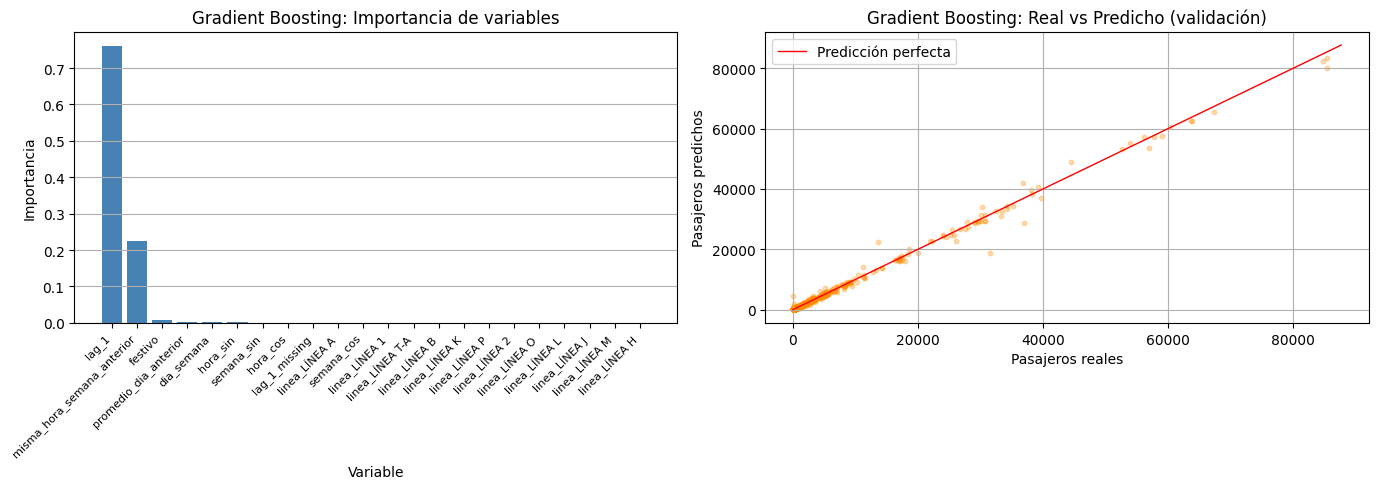

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Importancia de variables
importancias = modelo_final.feature_importances_
nombres = X_train.columns
indices = np.argsort(importancias)[::-1]

axes[0].bar(range(len(nombres)), importancias[indices], color="steelblue")
axes[0].set_xticks(range(len(nombres)))
axes[0].set_xticklabels(nombres[indices], rotation=45, ha="right", fontsize=8)
axes[0].set_xlabel("Variable")
axes[0].set_ylabel("Importancia")
axes[0].set_title("Gradient Boosting: Importancia de variables")
axes[0].grid(axis="y")

# Gráfica 2: Real vs Predicho en validación
sample_idx = np.random.choice(len(y_validation), size=1000, replace=False)
axes[1].scatter(
    y_validation.iloc[sample_idx],
    pred_val[sample_idx],
    alpha=0.3, s=10, color="darkorange"
)
max_val = max(y_validation.max(), pred_val.max())
axes[1].plot([0, max_val], [0, max_val], color="red", linewidth=1, label="Predicción perfecta")
axes[1].set_xlabel("Pasajeros reales")
axes[1].set_ylabel("Pasajeros predichos")
axes[1].set_title("Gradient Boosting: Real vs Predicho (validación)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()